Целевыми переменными являются:
- IC50 - используется для определения минимальной ингибирующей концентрации для подавления 50% возбудителя
- CC50 - цитотоксическая концентрация экстрактов, вызывающая гибель 50% жизнеспособных клеток в организме хозяина
- SI - отношение СС50 к IC50 - терапевтический индекс

# Импорты

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Загрузка данных

In [ ]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО.xlsx')

# Первичный анализ

In [ ]:
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df= df.drop(columns=["Unnamed: 0"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


# Базовая очистка

In [ ]:
# удаление дубликатов
df = df.drop_duplicates()

# переименование столбцов
df = df.rename(columns={
    'IC50, mM': 'IC50',
    'CC50, mM': 'CC50'})

# Анализ структуры данных

In [ ]:
df.dtypes

,0
IC50,float64
CC50,float64
SI,float64
MaxAbsEStateIndex,float64
MaxEStateIndex,float64
...,...
fr_thiazole,int64
fr_thiocyan,int64
fr_thiophene,int64
fr_unbrch_alkane,int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IC50,969.0,220.726223,397.172441,0.003517,12.515396,45.338355,231.373089,4128.529377
CC50,969.0,586.419908,633.624464,0.700808,99.999345,424.166213,891.776925,4538.976189
SI,969.0,73.967907,695.564665,0.011489,1.488095,3.900000,16.375000,15620.600000
MaxAbsEStateIndex,969.0,10.893712,3.284005,2.321942,10.006389,12.196496,13.178870,15.933463
MaxEStateIndex,969.0,10.893712,3.284005,2.321942,10.006389,12.196496,13.178870,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,969.0,0.053664,0.225469,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,969.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,969.0,0.070175,0.255574,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,969.0,0.208462,1.231428,0.000000,0.000000,0.000000,0.000000,20.000000


# Анализ пропусков и признаков

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print(missing)

MinAbsPartialCharge    3
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MRLOW           3
BCUT2D_MRHI            3
BCUT2D_LOGPLOW         3
BCUT2D_LOGPHI          3
BCUT2D_CHGLO           3
BCUT2D_CHGHI           3
BCUT2D_MWLOW           3
dtype: int64


Большинство признаков не содержат пропусков

In [ ]:
df = df.fillna(df.median())

In [ ]:
constant_cols = df.columns[df.nunique(dropna=True) <= 1]

print("Константные признаки:", len(constant_cols))
print(constant_cols)

df.drop(columns=constant_cols, inplace=True)

Константные признаки: 18
Index(['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH',
       'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
       'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
       'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd',
       'fr_thiocyan'],
      dtype='object')


Удалим константные признаки (признаки с единственным уникальным значением), поскольку они не содержат информации, позволяющей различать объекты выборки и не могут участвовать в формировании предсказаний модели, а их удаление ускоряет работу моделей

# Анализ таргетов

In [ ]:
targets = ['IC50', 'CC50', 'SI']

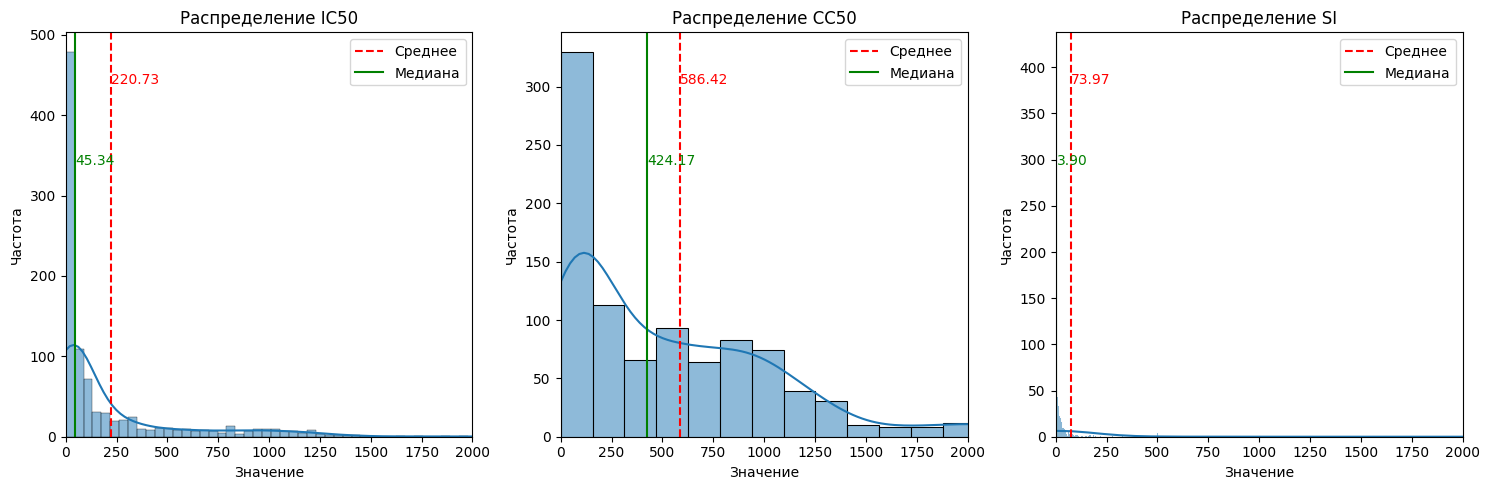

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, targets):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Распределение {col}')
    ax.set_xlim(0, 2000)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Частота')

    mean_val = df[col].mean()
    median_val = df[col].median()

    ax.axvline(mean_val, color='red', linestyle='--', label='Среднее')
    ax.axvline(median_val, color='green', linestyle='-', label='Медиана')

    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 0.9, f"{mean_val:.2f}", color='red', verticalalignment='top')
    ax.text(median_val, ymax * 0.7, f"{median_val:.2f}", color='green', verticalalignment='top')
    ax.legend()

plt.tight_layout()
plt.show()

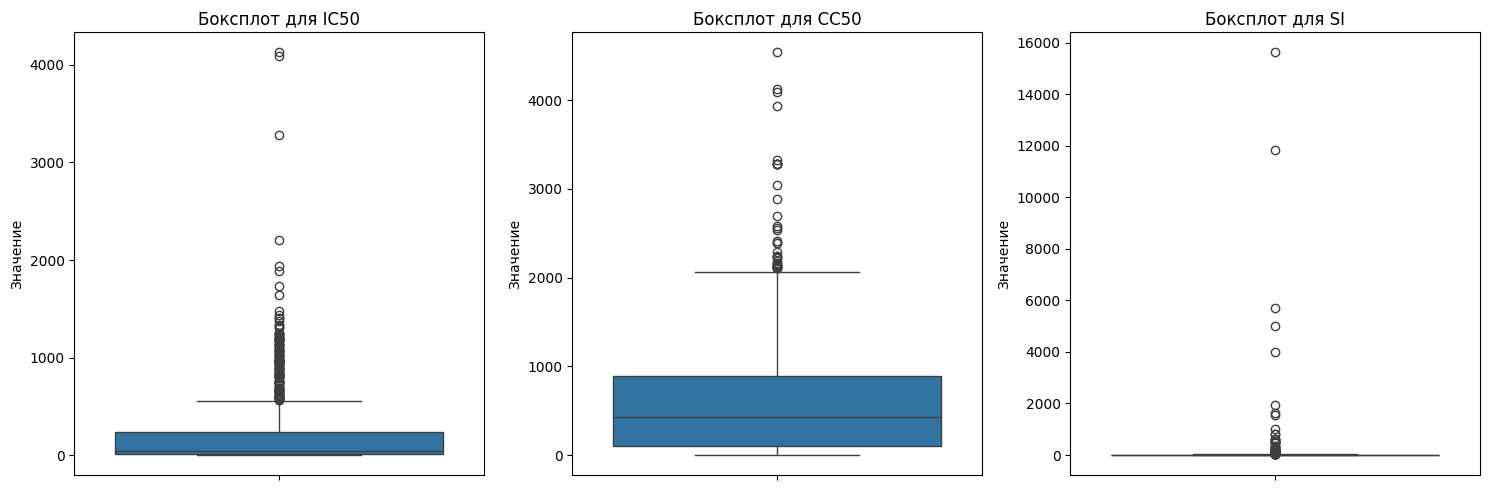

In [ ]:
# боксплоты
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, targets):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Боксплот для {col}')
    ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

In [ ]:
outlier_stats = {}

for col in targets:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    total = df[col].shape[0]

    outlier_pct = outliers / total * 100
    outlier_stats[col] = outlier_pct

outlier_stats = dict(sorted(outlier_stats.items(), key=lambda x: x[1], reverse=True))

for col, pct in outlier_stats.items():
    print(f"{col}: {pct:.2f}% выбросов")

IC50: 14.24% выбросов
SI: 12.38% выбросов
CC50: 3.61% выбросов


- Таргеты имеют выраженную правостороннюю асимметрию.
- Присутствуют выбросы.

### Логарифмируем таргеты для уменьшения асимметрии распределений и снижения влияния экстремальных значений

In [ ]:
# логарифмирование таргетов
log_df = pd.DataFrame({
    "IC50_log": np.log1p(df["IC50"]),
    "CC50_log": np.log1p(df["CC50"]),
    "SI_log": np.log1p(df["SI"])
})

df = pd.concat([df, log_df], axis=1)

log_targets = ['IC50_log', 'CC50_log', 'SI_log']

# Анализ распределений признаков

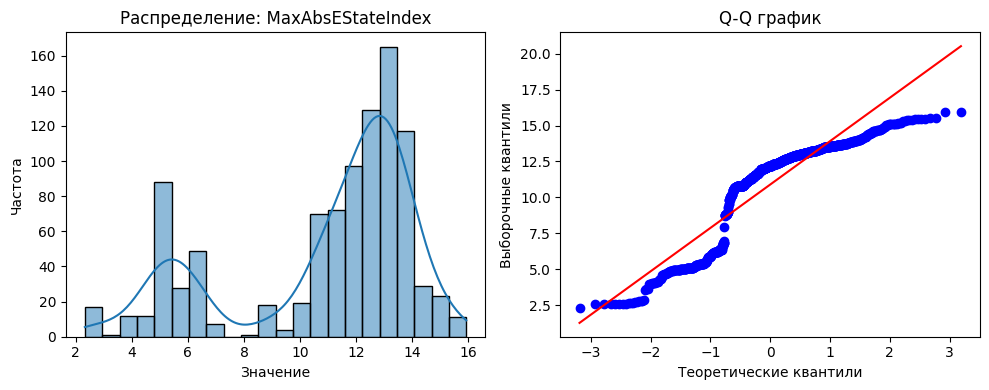

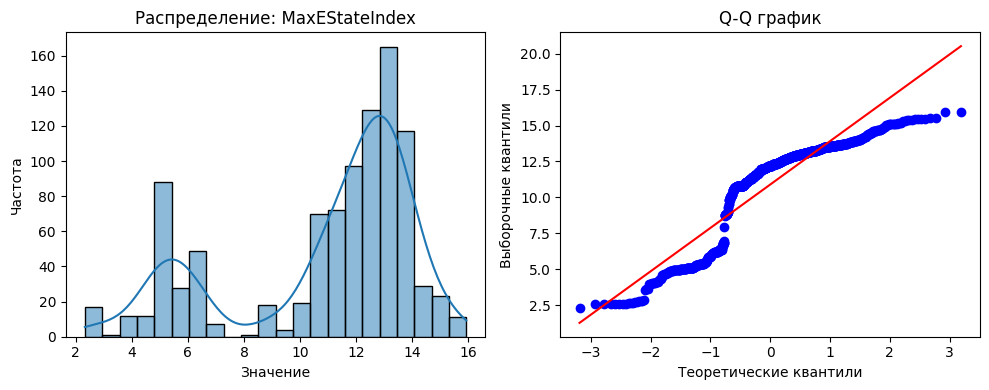

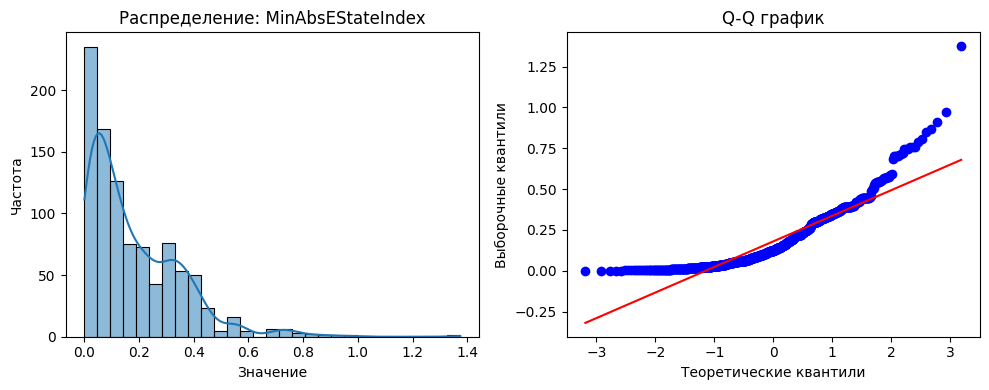

In [ ]:
numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ['IC50', 'CC50', 'SI',
                   'IC50_log', 'CC50_log', 'SI_log']
][:3]

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    stats.probplot(df[col].dropna(), dist="norm", plot=ax[1])

    ax[0].set_title(f"Распределение: {col}")
    ax[0].set_xlabel("Значение")
    ax[0].set_ylabel("Частота")

    ax[1].set_title("Q-Q график")
    ax[1].set_xlabel("Теоретические квантили")
    ax[1].set_ylabel("Выборочные квантили")

    plt.tight_layout()
    plt.show()

На графиках (Q-Q plot) видно, что большинство молекулярных дескрипторов также отклоняются от нормального распределения. Это характерно для химических данных, где многие параметры имеют дискретную природу или выраженную асимметрию

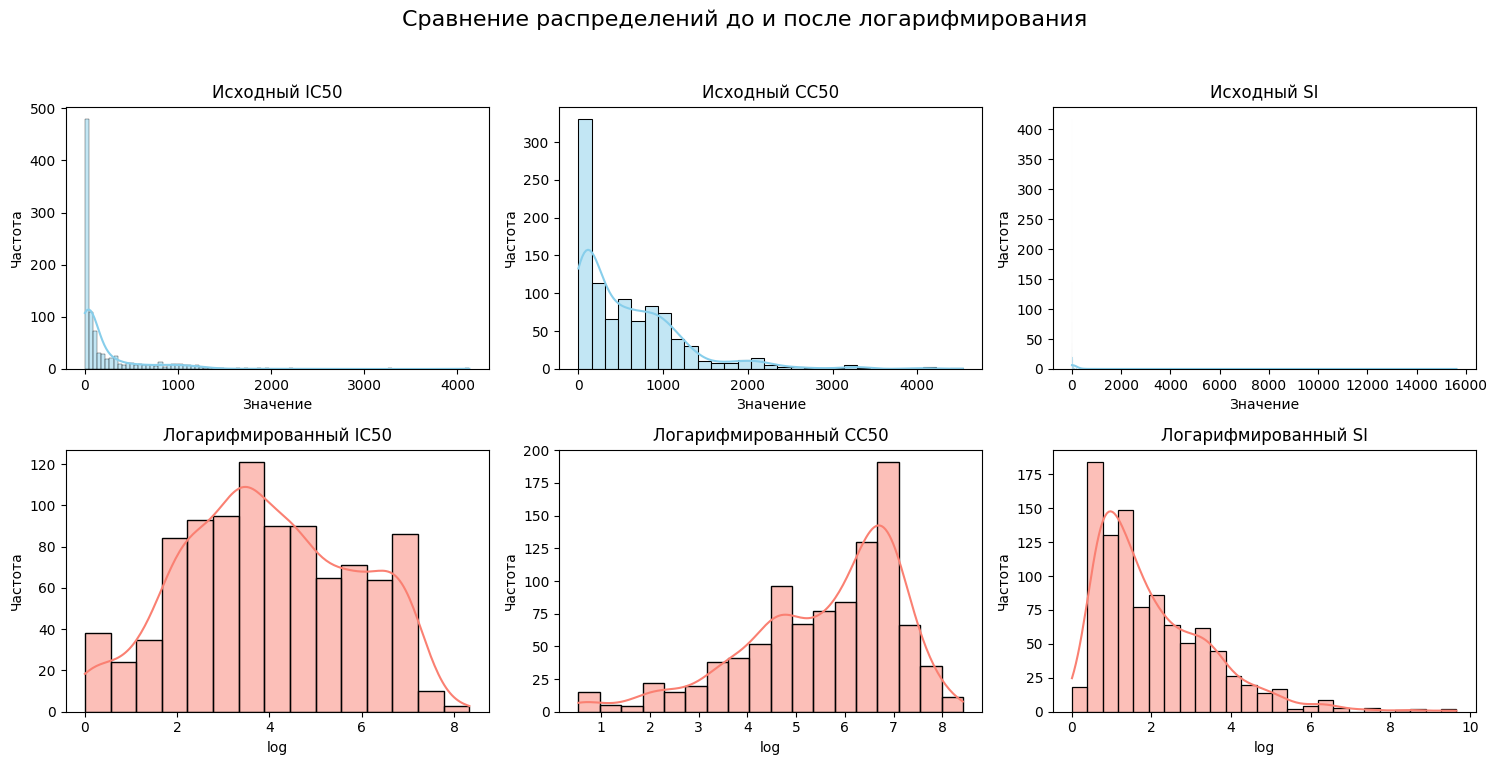

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Исходный {col}')
    axes[0, i].set_xlabel('Значение')
    axes[0, i].set_ylabel('Частота')

    sns.histplot(df[log_targets[i]], kde=True, ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'Логарифмированный {col}')
    axes[1, i].set_xlabel('log')
    axes[1, i].set_ylabel('Частота')

plt.suptitle('Сравнение распределений до и после логарифмирования', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Исходные данные (верхний ряд)

- Распределения имеют выраженный правосторонний сдвиг (асимметрию)
- Большая часть значений «скучивается» в левой части графика (малые значения)
- Правый «хвост» (высокие значения) практически не виден, так как он сильно сжат из-за линейного масштаба оси
- Это типичная картина для логнормального распределения, где значения охватывают несколько порядков величины

## Логарифмированные данные (нижний ряд)

- Форма распределений становится намного ближе к нормальному (колоколообразному)
- Данные равномерно распределены по оси X, что позволяет увидеть структуру и пики в области средних и высоких значений
- «Хвост» справа перестал доминировать визуально, а «скученность» слева исчезла.

### Логарифмическое преобразование позволило:

- снизить влияние экстремальных значений
- уменьшить асимметрию распределений
- приблизить распределения к нормальному виду
- стабилизировать дисперсию целевых переменных

В дальнейшем при построении регрессионных моделей целесообразно протестировать как исходные, так и логарифмированные варианты целевых переменных.

# Корреляционный анализ

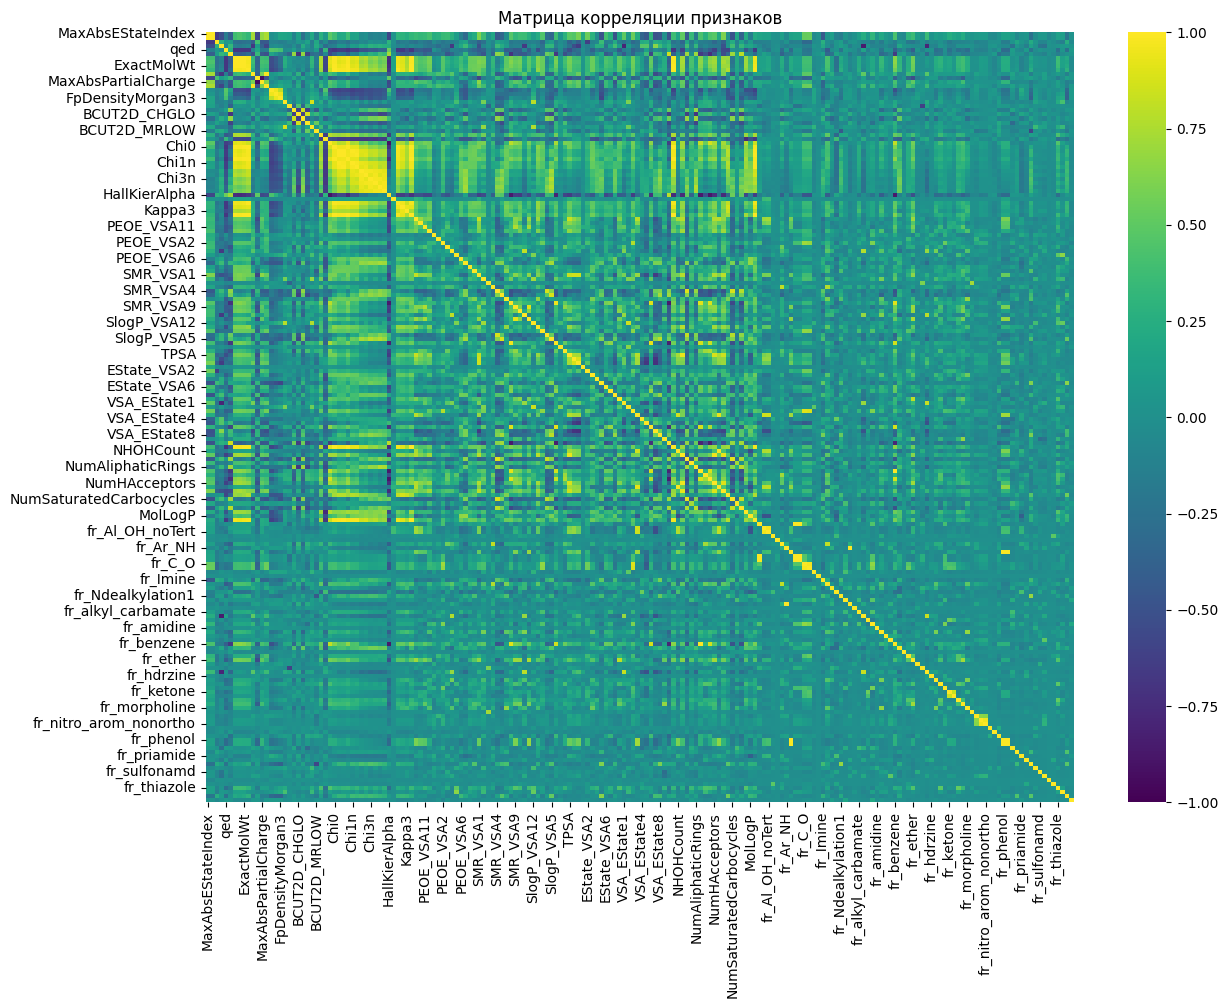

In [ ]:
feature_cols = df.drop(columns=['IC50', 'CC50', 'SI',
                                'IC50_log', 'CC50_log', 'SI_log'],
                       errors='ignore')

corr = feature_cols.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='viridis', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков")
plt.show()

In [ ]:
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

corr_pairs = (
    corr.where(mask)
        .stack()
        .reset_index())

corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

corr_pairs.sort_values('Correlation', key=abs, ascending=False).head(10)

,Feature_1,Feature_2,Correlation
14975,NumAromaticCarbocycles,fr_benzene,1.000000
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
18216,fr_phenol,fr_phenol_noOrthoHbond,1.000000
16333,fr_Ar_NH,fr_Nhpyrrole,1.000000
16445,fr_COO,fr_COO2,1.000000
1132,MolWt,ExactMolWt,0.999999
5527,Chi1,HeavyAtomCount,0.998736
1131,MolWt,HeavyAtomMolWt,0.996861
1316,HeavyAtomMolWt,ExactMolWt,0.996830
5044,Chi0,HeavyAtomCount,0.995968


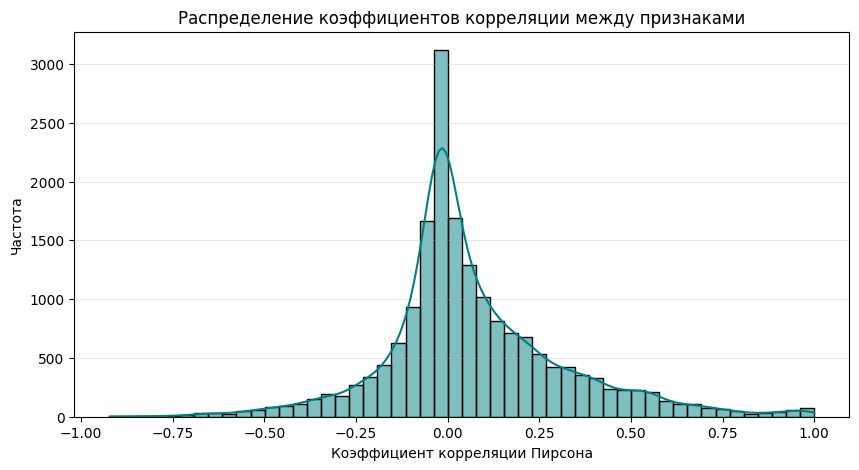

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(corr_pairs['Correlation'], bins=50, kde=True, color='teal')
plt.title('Распределение коэффициентов корреляции между признаками')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Разберемся с корреляцией

In [ ]:
high_corr = corr_pairs[abs(corr_pairs['Correlation']) > 0.9]

print(
    f"Доля сильно коррелирующих пар: "
    f"{len(high_corr) / len(corr_pairs) * 100:.2f}%")

print("Сильные корреляции (>0.9):", len(high_corr))
high_corr.head(20)

Доля сильно коррелирующих пар: 0.84%
Сильные корреляции (>0.9): 154


,Feature_1,Feature_2,Correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
1131,MolWt,HeavyAtomMolWt,0.996861
1132,MolWt,ExactMolWt,0.999999
1133,MolWt,NumValenceElectrons,0.981015
1151,MolWt,BertzCT,0.901766
1152,MolWt,Chi0,0.986580
1153,MolWt,Chi0n,0.935012
1154,MolWt,Chi0v,0.953700
1155,MolWt,Chi1,0.987095
1156,MolWt,Chi1n,0.904506


In [ ]:
to_drop = set()
for index, row in high_corr.iterrows():
    if row['Feature_1'] not in to_drop:
        to_drop.add(row['Feature_2'])

df = df.drop(columns=list(to_drop), errors='ignore')

print(f"Удалено признаков: {len(to_drop)}")
print(f"Новая размерность датафрейма: {df.shape}")

Удалено признаков: 40
Новая размерность датафрейма: (969, 158)


In [ ]:
df[['IC50', 'CC50', 'SI']].corr()

,IC50,CC50,SI
IC50,1.000000,0.516589,-0.057035
CC50,0.516589,1.000000,-0.006169
SI,-0.057035,-0.006169,1.000000


- Между IC50 и CC50 наблюдается умеренная положительная корреляция (≈0.52), что указывает на частичную связь между биологической активностью соединений и их токсичностью.
- В то же время SI демонстрирует практически нулевую линейную корреляцию с обеими переменными, что объясняется нелинейной природой данного показателя (CC50 / IC50) и особенностями распределений исходных данных.

# Итоговый вывод по результатам EDA

В ходе разведочного анализа данных (EDA) были выполнены следующие ключевые этапы:

1.  Очистка и предобработка:
    *   Удалены дубликаты и строки с пропущенными значениями
    *   Исключены 18 константных признаков, не несущих полезной информации для моделей

2.  Анализ целевых переменных:
    *   Выявлена сильная правосторонняя асимметрия в показателях IC50, CC50 и SI. Средние значения значительно превышают медианы из-за наличия «длинных хвостов»
    *   Зафиксировано значительное количество статистических выбросов
    *   Применено логарифмическое преобразование, которое успешно нормализовало распределения таргетов и снизило влияние экстремальных значений

3.  Корреляционный анализ:
    *   Обнаружена умеренная связь между активностью (IC50) и токсичностью (CC50) (corr ≈ 0.52).
    * Было удалено 40 пар сильно коррелирующих признаков

4.  Готовность к обучению:
    *   Сформированы два набора целевых переменных: исходные и логарифмированные.
    *   Данные полностью подготовлены для обучения

In [ ]:
# Сохранить df в CSV файл
df.to_csv('df.csv', index=False)